# Data Notes

## Purpose
- Track data sources, preprocessing, and known issues.
- Log anomalies (e.g., NaNs, missing times) with reproducible steps.
- Keep links to runs, configs, and artifacts tied to data changes.

## Dataset Inventory
| Dataset          | Resolution | Grid type | Temporal coverage | Original spatial coverage | Cropping to NYS grid coverage | Notes |
|------------------|------------|-----------|-------------------|---------------------------|-------------------------------|-------|
| RTMA             |2.5 x 2.5 km| lat lon    |  2018 to 2025    | CONUS                     | yes                           | RTMA precipitation is is on a different grid compared to the other variables       |
| URMA             |2.5 x 2.5 km| lat lon    |  2014 to 2025    | CONUS                     | yes                           | All variables are on same grid, which is also similar to the RTMA grid      |
| CONUS404         |4 x 4 km    | lat lon    | 1979 - 2025     | CONUS                     | yes                           |       |
| ERA5             |0.25 x 0.25 deg | lat lon | 1940 to 2025    | Global                    | yes                           |       |
| EDDE Historical             | 12.5 km    | lat lon | 1985-2014| Global                    | yes                           |       |
| EDDE SSP2-4.5             | 12.5 km    | lat lon | 2025-2100| Global                    | yes                           |       || EDDE SSP2-4.5             | 12.5 km    | lat lon | 2025-2100| Global                    | yes                           |       |
| EDDE SSP3-7.0             | 12.5 km    | lat lon | 2025-2100| Global                    | yes                           |       |
| ICON-DREAM       | 13 km    | unstructured | 2010-2025        | Global                    | yes                           |       |
| Auxiliary/static | 90 m       | m         | Static            | Global                    | yes                           |       |


In [1]:
import os
os.chdir('/network/rit/lab/basulab/Harish/met-data-products')

## RTMA

### Read sample data of full orography and precipitation, to find their underlying grid

In [10]:
import xarray as xr
rtma_hgt = xr.open_dataset('RTMA/samples/hgt.grb2',engine='cfgrib', backend_kwargs={'indexpath':''})
rtma_precip = xr.open_dataset('RTMA/samples/rtma2p5.2020010100.pcp.184.grb2',
                            engine='cfgrib', backend_kwargs={'indexpath':'','filter_by_keys': {'shortName': 'tp'}} )
print("RTMA orography grid:", rtma_hgt.sizes, "RTMA precipitation gird:",rtma_precip.sizes)

RTMA orography grid: Frozen({'y': 1597, 'x': 2345}) RTMA precipitation gird: Frozen({'y': 1377, 'x': 2145})


- This clearly tells that the RTMA grid for precipitaiton doesn't match the grid of the rest of the variables, including the orography.
- This becomes an issue when we crop the precipitation data to the NYS domain.

## URMA
- More details about this data can be found at https://gribstream.com/models/urma, https://docs.google.com/document/d/1JEnLktenBgAFFOJ17XRBFsJVOvTATUjM9nnp_cDjfbE/edit?tab=t.0
- Take a look at this document https://www.weather.gov/media/notification/pdf2/scn20-45rtma_2.8_aab.pdf, where it was mentioned that snow is added to precipitation URMA

### Reading sample files to find their variables names inside and corresponding var attributes

In [2]:
import xarray as xr
GRIB_SHORTNAME = {
    "si10": "10si",       # wind speed at 10 m
    "i10fg": "i10fg",     # wind gust at 10 m
    "t2m": "2t",          # 2 m air temperature
    "sp": "sp",           # surface pressure
    "d2m": "2d",          # 2 m dew point
    "u10": "10u",         # eastward wind at 10 m
    "v10": "10v",         # northward wind at 10 m
    "sh2": "2sh",         # 2 m specific humidity
    "wdir10": "10wdir",   # 10 m wind direction
    "tp": "tp",           # total precipitation
}
for var, shortname in GRIB_SHORTNAME.items():
    file = 'URMA/samples/urma2p5.t00z.2dvaranl_ndfd.grb2_wexp' if var != 'tp' else 'URMA/samples/urma2p5.2020010100.pcp_01h.wexp.grb2'
    ds = xr.open_dataset(file,engine='cfgrib', backend_kwargs={'indexpath':'','filter_by_keys': {'shortName': shortname}} )
    candidates = [v for v in ds.data_vars if v not in {"lat", "lon", "time", "mtime"}]
    data_var = candidates[0] if candidates else next(iter(ds.data_vars))
    print(var, data_var, ds.sizes, ds[data_var].attrs.get("long_name"), ds[data_var].attrs.get("units"))
    if var == 'tp':
        print('For precipitation ',ds[data_var].attrs)
    ds.close()

/opt/miniconda3/envs/DFSAI/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


si10 si10 Frozen({'y': 1597, 'x': 2345}) 10 metre wind speed m s**-1
i10fg i10fg Frozen({'y': 1597, 'x': 2345}) Instantaneous 10 metre wind gust m s**-1
t2m t2m Frozen({'y': 1597, 'x': 2345}) 2 metre temperature K
sp sp Frozen({'y': 1597, 'x': 2345}) Surface pressure Pa
d2m d2m Frozen({'y': 1597, 'x': 2345}) 2 metre dewpoint temperature K
u10 u10 Frozen({'y': 1597, 'x': 2345}) 10 metre U wind component m s**-1
v10 v10 Frozen({'y': 1597, 'x': 2345}) 10 metre V wind component m s**-1
sh2 sh2 Frozen({'y': 1597, 'x': 2345}) 2 metre specific humidity kg kg**-1
wdir10 wdir10 Frozen({'y': 1597, 'x': 2345}) 10 metre wind direction Degree true
tp tp Frozen({'y': 1597, 'x': 2345}) Total Precipitation kg m**-2
For precipitation  {'GRIB_paramId': 228228, 'GRIB_dataType': 'fc', 'GRIB_numberOfPoints': 3744965, 'GRIB_typeOfLevel': 'surface', 'GRIB_stepUnits': 1, 'GRIB_stepType': 'accum', 'GRIB_gridType': 'lambert', 'GRIB_uvRelativeToGrid': 1, 'GRIB_DxInMetres': 2539.703, 'GRIB_DyInMetres': 2539.703, 

- Snowfall is different, doesn't have a variable name.

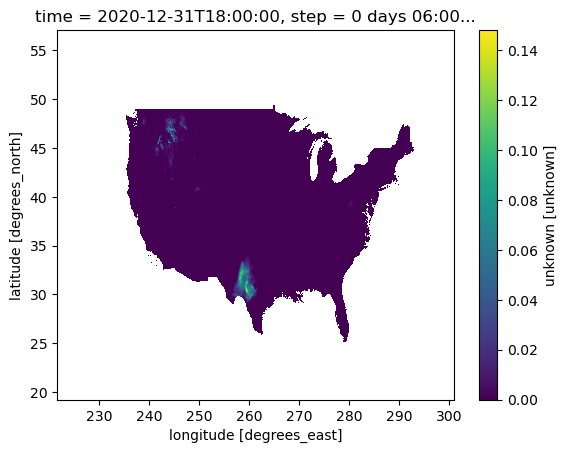

In [3]:
xr.open_dataset('URMA/samples/snowfall_wexp.2021010100.06h.grb2',engine='cfgrib', backend_kwargs={'indexpath':''})['unknown'].plot(
    x='longitude', y='latitude')

- The units of variables will be subjective to the dataset. To have a consistnecy, follow the units of URMA throughout. 
- More specifically, precipitation will be either in m, mm, or kg m**-2. The kg m**-2 is equivalent to mm.
- So, convertion from mm to kg m**-2 is 1, m to kg m**-2 is 1e3
- If pressure is in hPa, conversion to Pa is 1e2

- Based on the output, the following dictonary is used throughout this project. 

In [ ]:
VAR_UNITS = {
    "si10": "m s**-1",        # 10 metre wind speed
    "i10fg": "m s**-1",       # Instantaneous 10 metre wind gust
    "t2m": "K",               # 2 metre temperature
    "sp": "Pa",               # Surface pressure
    "d2m": "K",               # 2 metre dewpoint temperature
    "u10": "m s**-1",         # 10 metre U wind component
    "v10": "m s**-1",         # 10 metre V wind component
    "sh2": "kg kg**-1",       # 2 metre specific humidity
    "wdir10": "Degree true",  # 10 metre wind direction
    "tp": "kg m**-2",         # Total Precipitation
}

### Doing a sanity check for precipitation to find if it is accumulated of instanteneous

In [ ]:
import URMA.process_and_write_to_zarr as urma_p
ds = urma_p.daily_processing("tp", "20200101", 24, -1, -1)

import matplotlib.pyplot as plt

# 24 time steps -> 4x6
fig, axes = plt.subplots(4, 6, figsize=(18, 10), constrained_layout=True)
axes = axes.ravel()

for t in range(24):
    ds.tp.isel(time=t).plot(ax=axes[t], add_colorbar=False)
    axes[t].set_title(str(ds.time.values[t]))

plt.show()

- From the above figure, it is clear that the precipitation is not accumulated over each hour. 
- However, it is still not possible to say if the precipitation is accumulated over that year or instanteneous at the end of the year. 

### Read sample data of full orography and precipitation, to find their underlying grid

In [6]:
import xarray as xr
import numpy as np
urma_hgt = xr.open_dataset('URMA/samples/urma2p5.t00z.2dvaranl_ndfd.grb2_wexp',
                           engine='cfgrib', backend_kwargs={'indexpath':'','filter_by_keys': {'shortName': 'orog'}} )
urma_precip = xr.open_dataset('URMA/samples/urma2p5.2020010100.pcp_01h.wexp.grb2',
                           engine='cfgrib', backend_kwargs={'indexpath':'','filter_by_keys': {'shortName': 'tp'}} )
lat_equal = np.allclose(urma_hgt.latitude.values, urma_precip.latitude.values, atol=1e-12)
lon_equal = np.allclose(urma_hgt.longitude.values, urma_precip.longitude.values, atol=1e-12)

lat_equal, lon_equal

(True, True)

- It is also confirmed that the RTMA and URMA orography have similar grids, that also follows to the other variables. 
- Only RTMA precipitation is on a different grid. 
- The take away is, RTMA data processing scripts will work for URMA. 

### Crop to the NYS

In [4]:
nx, ny = 288, 256
x_start, x_end = 1800, 1800 + nx
y_start, y_end = 830, 830 + ny
def preprocess(ds):
    return ds.isel(y=slice(y_start,y_end),x=slice(x_start,x_end))

In [7]:
urma_hgt_sub = preprocess(urma_hgt)
urma_hgt_sub = urma_hgt_sub.drop_vars(['time','step','surface','valid_time'])
# Add CF attributes so CDO recognizes the grid
urma_hgt_sub["latitude"].attrs = {
    "standard_name": "latitude",
    "units": "degrees_north"
}
urma_hgt_sub["longitude"].attrs = {
    "standard_name": "longitude",
    "units": "degrees_east"
}

# Very important: add coordinates attribute to variables
urma_hgt_sub["orog"].attrs = {"coordinates": "latitude longitude"}

urma_hgt_sub

<xarray.Dataset> Size: 1MB
Dimensions:    (y: 256, x: 288)
Coordinates:
    latitude   (y, x) float64 590kB 40.73 40.73 40.73 40.73 ... 45.31 45.31 45.3
    longitude  (y, x) float64 590kB 279.9 279.9 279.9 ... 289.3 289.3 289.4
Dimensions without coordinates: y, x
Data variables:
    orog       (y, x) float32 295kB ...
Attributes:
    GRIB_edition:            2
    GRIB_centre:             kwbc
    GRIB_centreDescription:  US National Weather Service - NCEP
    GRIB_subCentre:          4
    Conventions:             CF-1.7
    institution:             US National Weather Service - NCEP
    history:                 2026-06-09T11:00 GRIB to CDM+CF via cfgrib-0.9.1...

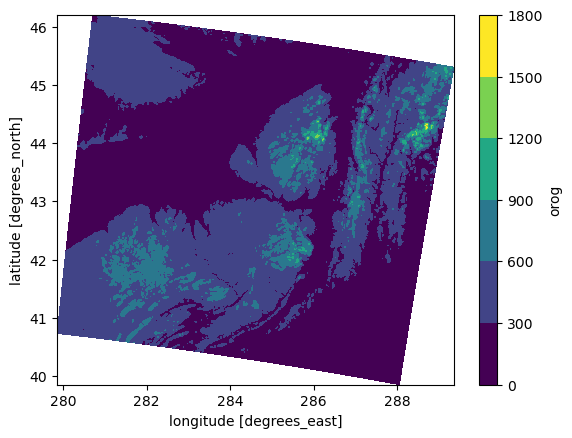

In [8]:
urma_hgt_sub.orog.plot.contourf(x='longitude', y='latitude')

### URMA HR $(256 \times 288)$ -> URMA Full LR $(256/5 \times 288/5)$ generation
- In examining the influence of training strategy, we would go from LR URMA input to HR URMA targets. 
- The LR URMA should ideally have similar distributional stats of the intended LR data, which is the EDDEv2.
-  Here, we could examine 3-4 methods for generation: bilinear, nearest neighbor, conservative, and uniform filter as optional. 
- Since we are going from same source (URMA), there is no need for xesmf.

A-cons (conservative)                          sizes={'y': 52, 'x': 58}  domain mean= 286.580  (HR mean= 287.803)
A-bilin (bilinear)                             sizes={'y': 52, 'x': 58}  domain mean= 285.696  (HR mean= 287.803)
A-cubic (cubic)                                sizes={'y': 52, 'x': 58}  domain mean= 284.938  (HR mean= 287.803)
uniform_filter+stride (current _urma_to_lr)    sizes={'y': 52, 'x': 58}  domain mean= 286.709  (HR mean= 287.803)


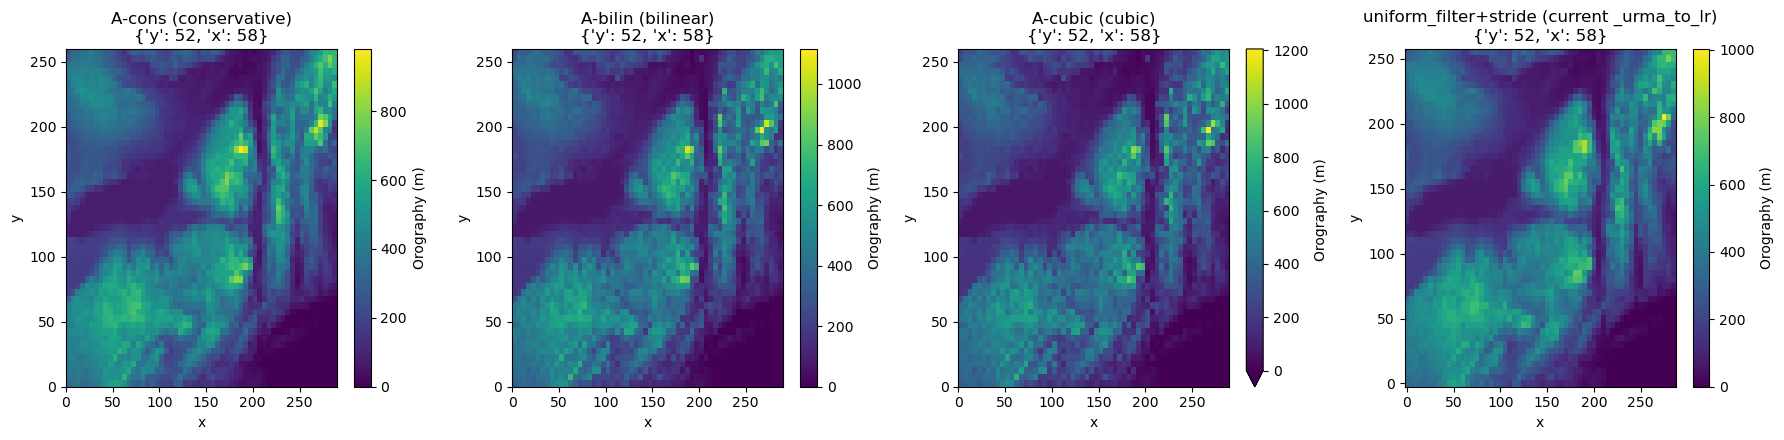

A-cons (conservative)  vs  A-bilin (bilinear):  std of diff = 35.6680  (0 = identical — bad)
A-bilin (bilinear)  vs  A-cubic (cubic):  std of diff = 14.8251  (0 = identical — bad)
A-cons (conservative)  vs  A-cubic (cubic):  std of diff = 47.4725  (0 = identical — bad)


In [10]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy.ndimage import uniform_filter

hr = urma_hgt_sub["orog"].drop_vars(["latitude", "longitude"], errors="ignore")
hr = hr.assign_coords(y=("y", np.arange(hr.sizes["y"])), x=("x", np.arange(hr.sizes["x"])))

sy, sx = 5, 5

ny_lr = -(-hr.sizes["y"] // sy)   # ceil(256/5) = 52
nx_lr = -(-hr.sizes["x"] // sx)   # ceil(288/5) = 58

# xesmf-style grid definition: corners (cell boundaries) first, centers derived.
# Matches the lat_b / lat convention in xesmf:
#   corners  [0, 5, 10, ..., 260]  — cell boundary positions (53 / 59 values)
#   centers  [2.5, 7.5, ..., 257.5] — midpoints of each cell (52 / 58 values)
y_corners = np.arange(ny_lr + 1) * sy          # [0, 5, 10, ..., 260]
y_centers = y_corners[:-1] + sy / 2.0          # [2.5, 7.5, ..., 257.5]
x_corners = np.arange(nx_lr + 1) * sx          # [0, 5, 10, ..., 290]
x_centers = x_corners[:-1] + sx / 2.0          # [2.5, 7.5, ..., 287.5]

# Padding needed so that bilinear/cubic can interpolate at the last center (257.5)
# which lies beyond the HR domain edge (y=255).  Edge-pad extends the domain
# to exactly ny_lr * sy rows so all centers fall within the padded range.
pad_y = ny_lr * sy - hr.sizes["y"]   # = 4
pad_x = nx_lr * sx - hr.sizes["x"]  # = 2


def _reindex(da):
    """Assign contiguous float index coords (required by xr.interp)."""
    return da.assign_coords(
        y=("y", np.arange(da.sizes["y"], dtype=float)),
        x=("x", np.arange(da.sizes["x"], dtype=float)),
    )


def to_lr_bilinear(da):
    d = _reindex(da.pad(y=(0, pad_y), x=(0, pad_x), mode="edge"))
    return d.interp(y=y_centers, x=x_centers, method="linear",
                    kwargs={"fill_value": None, "bounds_error": False})


def to_lr_cubic(da):
    d = _reindex(da.pad(y=(0, pad_y), x=(0, pad_x), mode="edge"))
    return d.interp(y=y_centers, x=x_centers, method="cubic",
                    kwargs={"fill_value": None, "bounds_error": False})


def to_lr_conservative(da):
    result = (
        da.pad(y=(0, pad_y), x=(0, pad_x), mode="edge")
          .coarsen(y=sy, x=sx, boundary="exact")
          .mean()
    )
    return result.assign_coords(y=("y", y_centers), x=("x", x_centers))


def to_lr_uniform_filter(da):
    # Reference: current _urma_to_lr (overlapping box-smooth + corner-node stride).
    filt = xr.DataArray(
        uniform_filter(da.values, size=(sy, sx), mode="nearest"),
        dims=da.dims, coords=da.coords,
    )
    return filt.isel(y=slice(0, None, sy), x=slice(0, None, sx))


lr_variants = {
    "A-cons (conservative)": to_lr_conservative(hr),
    "A-bilin (bilinear)":    to_lr_bilinear(hr),
    "A-cubic (cubic)":       to_lr_cubic(hr),
    "uniform_filter+stride (current _urma_to_lr)": to_lr_uniform_filter(hr),
}

fig, axs = plt.subplots(1, len(lr_variants), figsize=(4.5 * len(lr_variants), 4.5), squeeze=False)
for ax, (name, out) in zip(axs[0], lr_variants.items()):
    print(f"{name:46s} sizes={dict(out.sizes)}  "
          f"domain mean={float(out.mean()):8.3f}  (HR mean={float(hr.mean()):8.3f})")
    out.plot(ax=ax, vmin=0, cmap="viridis", cbar_kwargs={"label": "Orography (m)"})
    ax.set_title(f"{name}\n{dict(out.sizes)}")
plt.tight_layout()
plt.show()

# Sanity-check: all three operators must be mutually distinct
for a, b in [("A-cons (conservative)", "A-bilin (bilinear)"),
             ("A-bilin (bilinear)",    "A-cubic (cubic)"),
             ("A-cons (conservative)", "A-cubic (cubic)")]:
    d = float((lr_variants[a] - lr_variants[b]).std())
    print(f"{a}  vs  {b}:  std of diff = {d:.4f}  (0 = identical — bad)")


### URMA HR $(256 \times 288)$ -> URMA Full HR $(256 \times 288)$ generation
- This generation is just 1 step ahead of the above one.
- The only difference is that, the output will resolved to full size 256*288, but the resolution would still be degraded to that of EDDEv2 resolution (degraded to 12.5 km resolution)

A-cons  (cons down  + NN up)                     sizes={'y': 256, 'x': 288}  domain mean= 289.115  (HR mean= 287.803)
A-bilin (bilin down + bilin up)                  sizes={'y': 256, 'x': 288}  domain mean= 288.339  (HR mean= 287.803)
A-cubic (cubic down + cubic up)                  sizes={'y': 256, 'x': 288}  domain mean= 286.135  (HR mean= 287.803)
uniform_filter only (current io_ratio=[1,1] path) sizes={'y': 256, 'x': 288}  domain mean= 287.789  (HR mean= 287.803)


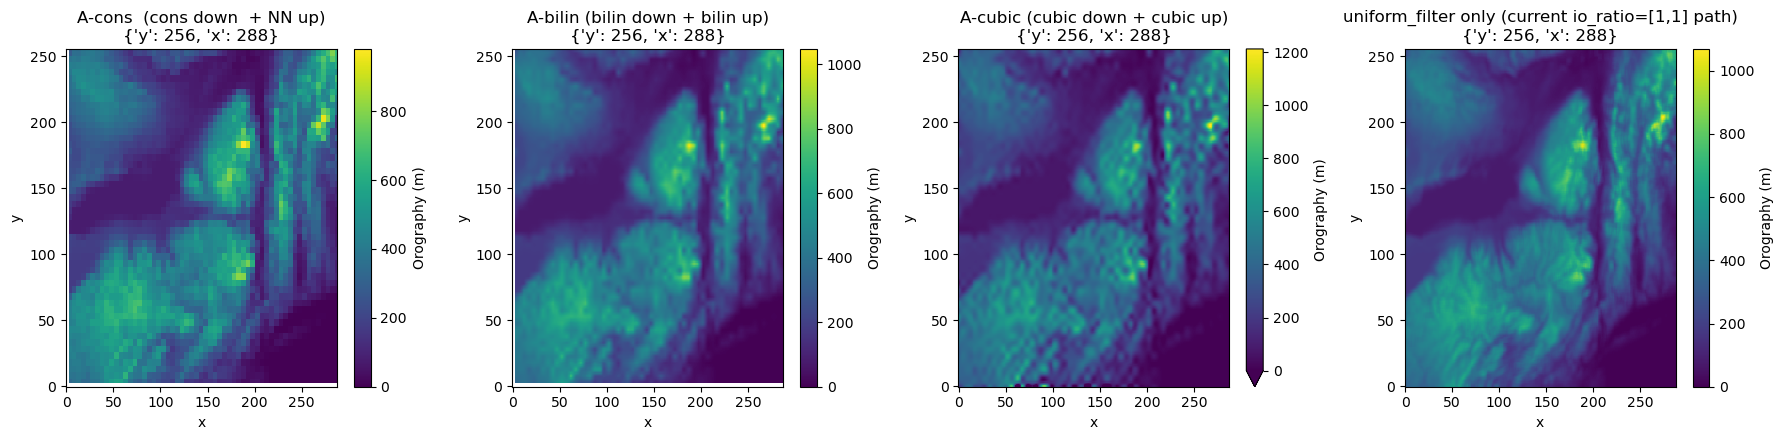

A-cons  (cons down  + NN up)  vs  A-bilin (bilin down + bilin up):  std = 38.4210
A-bilin (bilin down + bilin up)  vs  A-cubic (cubic down + cubic up):  std = 25.8780
A-cons  (cons down  + NN up)  vs  A-cubic (cubic down + cubic up):  std = 53.9254


In [11]:
def upsample_to_hr(lr_da, method):
    # Interpolate from cell-centre LR coords back to the full HR index grid.
    if method == "nearest":
        return lr_da.interp(y=hr["y"].values, x=hr["x"].values, method="nearest")
    return lr_da.interp(
        y=hr["y"].values, x=hr["x"].values, method=method,
        kwargs={"fill_value": None, "bounds_error": False},
    )


# Matched upsampling: each variant uses the same operator for both down and up.
#   A-cons : block-mean down  + NN up       -> block-replicate (constant per 5x5 patch)
#   A-bilin: bilinear down    + bilinear up  -> smooth round-trip
#   A-cubic: cubic down       + cubic up     -> smoother round-trip (higher-order)
full_hr_variants = {
    "A-cons  (cons down  + NN up)":      upsample_to_hr(lr_variants["A-cons (conservative)"], "nearest"),
    "A-bilin (bilin down + bilin up)":   upsample_to_hr(lr_variants["A-bilin (bilinear)"],    "linear"),
    "A-cubic (cubic down + cubic up)":   upsample_to_hr(lr_variants["A-cubic (cubic)"],       "cubic"),
}

# Reference: current io_ratio=[1,1] path (no decimation step, just smooth in-place)
full_hr_variants["uniform_filter only (current io_ratio=[1,1] path)"] = xr.DataArray(
    uniform_filter(hr.values, size=(sy, sx), mode="nearest"), dims=hr.dims, coords=hr.coords
)

fig, axs = plt.subplots(1, len(full_hr_variants), figsize=(4.5 * len(full_hr_variants), 4.5), squeeze=False)
for ax, (name, out) in zip(axs[0], full_hr_variants.items()):
    print(f"{name:48s} sizes={dict(out.sizes)}  "
          f"domain mean={float(out.mean()):8.3f}  (HR mean={float(hr.mean()):8.3f})")
    out.plot(ax=ax, vmin=0, cmap="viridis", cbar_kwargs={"label": "Orography (m)"})
    ax.set_title(f"{name}\n{dict(out.sizes)}")
plt.tight_layout()
plt.show()

# Sanity-check: all three matched variants must be mutually distinct
for a, b in [
    ("A-cons  (cons down  + NN up)",     "A-bilin (bilin down + bilin up)"),
    ("A-bilin (bilin down + bilin up)",  "A-cubic (cubic down + cubic up)"),
    ("A-cons  (cons down  + NN up)",     "A-cubic (cubic down + cubic up)"),
]:
    d = float((full_hr_variants[a] - full_hr_variants[b]).std())
    print(f"{a}  vs  {b}:  std = {d:.4f}")


## CONUS404

### Fetching data from microsoft planetary computer

In [ ]:
import pystac_client
import planetary_computer
import xarray as xr
cat = pystac_client.Client.open(
    "https://planetarycomputer.microsoft.com/api/stac/v1",
    modifier=planetary_computer.sign_inplace,
)

col = cat.get_collection("conus404")
asset = col.assets["zarr-abfs"]

print("Opening CONUS404 zarr dataset...")

ds_all = xr.open_zarr(
    asset.href,
    storage_options=asset.extra_fields.get("xarray:storage_options", {}),
    **asset.extra_fields.get("xarray:open_kwargs", {}),
)
ds_all

### writing the variables to a txt file

In [ ]:
with open("CONUS404/CONUS404_variable_descriptions_.txt", "w") as f:
    for var_name, da in ds_all.data_vars.items():
        f.write(f"Variable: {var_name}\n")
        for key, value in da.attrs.items():
            f.write(f"  {key}: {value}\n")
        f.write("\n")

In [ ]:
for var_name, da in ds_all.data_vars.items():
    if "bottom_top" in da.dims:
        print(f"{var_name}: {da.attrs.get('description', '')}, dims: {da.dims}")

In [ ]:
zarr_path = "/network/rit/lab/basulab/Projects/DFS/DATA/CONUS404_NYS/CONUS404_NYS.zarr"

xr.open_zarr(zarr_path,consolidated=False).sel(time=slice('1979','2022'))


### Extracting "geopotential height (Z in m^2/s^2`) and saving to nc file in m

In [ ]:
ds = ds_all.Z.sel(time='2020-01-01T00:00:00').isel(bottom_top_stag=0)
ds = ds.rename({'south_north':'y', 'west_east':'x'})
ds = (
    ds
    .assign_coords(
        latitude=(("y", "x"), ds.lat.values),
        longitude=(("y", "x"), ds.lon.values)
    )
    .drop_vars(["lat", "lon", "time"])
    .rename("orog")
)
lon_360 = (ds.longitude + 360) % 360
ds = ds.assign_coords(longitude=lon_360)
orog = ds.load()
orog.attrs['units'] = 'm'
orog.attrs['long_name'] = 'Geopotential Height'
orog.attrs['description'] = 'Units corrected from original source'

orog.to_netcdf('CONUS404/conus404_full_orography.nc')

### Crop CONUS404 to NYS boundary

In [ ]:
import numpy as np
import xarray as xr
orog = xr.open_dataset('CONUS404/conus404_full_orography.nc').orog
lat = orog.latitude.values
lon = orog.longitude.values

lat_min, lat_max = 38, 48
lon_min, lon_max = 278, 292

mask = (
    (lat >= lat_min) & (lat <= lat_max) &
    (lon >= lon_min) & (lon <= lon_max)
)

# Get bounding box indices
ys, xs = np.where(mask)

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

print(f"y: {y0}:{y1}, x: {x0}:{x1}")

orog_nys_cropped = orog.isel(y=slice(y0, y1), x=slice(x0, x1))

orog_nys_cropped.to_netcdf('CONUS404/conus404_nys_cropped_orography.nc')

orog_nys_cropped.plot.contourf(y='latitude',x='longitude',vmin=0)

### Examining the scale factor compared to URMA/RTMA

In [ ]:
import numpy as np

R = 6371.0088  # km

def haversine_km(lat1, lon1, lat2, lon2):
    lat1 = np.deg2rad(lat1); lon1 = np.deg2rad(lon1)
    lat2 = np.deg2rad(lat2); lon2 = np.deg2rad(lon2)
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return R * (2*np.arctan2(np.sqrt(a), np.sqrt(1-a)))

def as_2d(lat, lon):
    lat = np.asarray(lat); lon = np.asarray(lon)
    if lat.ndim == 1 and lon.ndim == 1:
        lon2d, lat2d = np.meshgrid(lon, lat)
        return lat2d, lon2d
    if lat.ndim == 2 and lon.ndim == 2:
        return lat, lon
    raise ValueError("lat/lon must be both 1D or both 2D")

def unwrap_lon(lon2d):
    # Remove 0/360 jumps along x
    return np.rad2deg(np.unwrap(np.deg2rad(lon2d), axis=1))

def _get_lat_lon(grid):
    lat_key = "lat" if "lat" in grid else ("latitude" if "latitude" in grid else None)
    lon_key = "lon" if "lon" in grid else ("longitude" if "longitude" in grid else None)
    if lat_key is None or lon_key is None:
        raise KeyError("grid must provide lat/latitude and lon/longitude")
    return grid[lat_key], grid[lon_key]

def _maybe_wrap_lon(lon):
    lon = np.asarray(lon)
    lon_min = np.nanmin(lon)
    lon_max = np.nanmax(lon)
    if lon_min >= 0 and lon_max <= 360:
        return ((lon + 180) % 360) - 180
    return lon

def roi_bbox_from_urma(urma_grid):
    lat_u, lon_u = as_2d(*_get_lat_lon(urma_grid))
    # Convert to -180..180 only if lon is 0..360
    lon_u = _maybe_wrap_lon(lon_u)
    return (float(np.nanmin(lat_u)), float(np.nanmax(lat_u)),
            float(np.nanmin(lon_u)), float(np.nanmax(lon_u)))

def subset_latlon_to_bbox(grid, bbox, halo_deg=1.0):
    lat2d, lon2d = as_2d(*_get_lat_lon(grid))
    lon = _maybe_wrap_lon(lon2d)

    latmin, latmax, lonmin, lonmax = bbox
    mask = ((lat2d >= latmin - halo_deg) & (lat2d <= latmax + halo_deg) &
            (lon >= lonmin - halo_deg) & (lon <= lonmax + halo_deg))

    yy, xx = np.where(mask)
    if yy.size == 0:
        raise ValueError("No points found in ROI; check lon convention / bbox.")
    y0, y1 = yy.min(), yy.max()
    x0, x1 = xx.min(), xx.max()

    lat_s = lat2d[y0:y1+1, x0:x1+1]
    lon_s = lon2d[y0:y1+1, x0:x1+1]
    return lat_s, lon_s

def spacing_stats_km_on_subset(lat_s, lon_s):
    lon_s = unwrap_lon(lon_s)
    dx = haversine_km(lat_s[:, :-1], lon_s[:, :-1], lat_s[:, 1:], lon_s[:, 1:])
    dy = haversine_km(lat_s[:-1, :], lon_s[:-1, :], lat_s[1:, :], lon_s[1:, :])
    dx = dx[np.isfinite(dx)]; dy = dy[np.isfinite(dy)]
    eff = float(np.sqrt(np.median(dx) * np.median(dy)))
    return {
        "dx_med": float(np.median(dx)), "dy_med": float(np.median(dy)),
        "dx_p10": float(np.percentile(dx, 10)), "dx_p90": float(np.percentile(dx, 90)),
        "dy_p10": float(np.percentile(dy, 10)), "dy_p90": float(np.percentile(dy, 90)),
        "eff": eff
    }

In [ ]:
import xarray as xr
conus404_nys_cropped = xr.open_dataset("CONUS404/conus404_nys_cropped_orography.nc")
urma_nys = xr.open_dataset("urma_nys_orography.nc")

bbox = roi_bbox_from_urma(urma_nys)

# URMA stats on its own grid (no halo)
lat_u, lon_u = as_2d(*_get_lat_lon(urma_nys))
urma_stats = spacing_stats_km_on_subset(lat_u, lon_u)

# CONUS404 stats restricted to the URMA ROI (+ halo)
lat_c404, lon_c404 = subset_latlon_to_bbox(conus404_nys_cropped, bbox, halo_deg=1.0)
conus404_stats = spacing_stats_km_on_subset(lat_c404, lon_c404)

print("URMA:", urma_stats)
print("CONUS404 ROI:", conus404_stats, "scale_eff:", conus404_stats["eff"]/urma_stats["eff"])

## ERA5

### Data source location
- `s3://nsf-ncar-era5/`

### Download invariant files

In [ ]:
!aws s3 cp --no-sign-request s3://nsf-ncar-era5/e5.oper.invariant/197901/e5.oper.invariant.128_172_lsm.ll025sc.1979010100_1979010100.nc ../ERA5/era5_full_lsm.nc

In [ ]:
!aws s3 cp --no-sign-request s3://nsf-ncar-era5/e5.oper.invariant/197901/e5.oper.invariant.128_129_z.ll025sc.1979010100_1979010100.nc ../ERA5/era5_full_z.nc

### Examine the full static data
- save to the ERA5 directory while reading

In [ ]:
import xarray as xr
# Open file safely
with xr.open_dataset('ERA5/era5_full_lsm.nc') as ds:
    lsm = ds.LSM.isel(time=0).drop_vars('time')
    lsm = lsm.load()   # ensure data is in memory

# Now the file is closed → safe to overwrite
lsm.to_netcdf('ERA5/era5_full_lsm.nc', mode='w')

# Plot
lsm.plot(x='longitude', y='latitude')

In [ ]:
import xarray as xr

z = xr.open_dataset('ERA5/era5_full_z.nc').Z
z = z.isel(time=0).drop_vars('time')

# Convert geopotential to height
g = 9.80665  # m s^-2
orog = z / g

# Clip to non-negative values
orog = orog.clip(min=0)

# Rename variable
orog = orog.rename("orog")

# Update attributes
orog.attrs["units"] = "m"
orog.attrs["long_name"] = "Orography (geopotential height)"
orog.attrs["comment"] = "Clipped to non-negative values"

# Save
orog.to_netcdf('ERA5/era5_full_orography.nc')

# Plot
orog.plot(x='longitude', y='latitude')

### Crop ERA5 to NYS boundary

In [ ]:
orog = xr.open_dataset('ERA5/era5_full_orography.nc').orog
orog.sel(latitude=slice(48,38),longitude=slice(278,292)).plot.contourf(x='longitude', y='latitude')

- The ERA5 orography is almost identical to the GFSp25

In [ ]:
orog_nys_cropped = orog.sel(latitude=slice(48,38),longitude=slice(278,292))
orog_nys_cropped.to_netcdf('../ERA5/era5_nys_cropped_orography.nc')

In [ ]:
lsm = xr.open_dataset('../ERA5/era5_full_lsm.nc').LSM
lsm.sel(latitude=slice(48,38),longitude=slice(278,292)).plot.contourf(x='longitude', y='latitude')

In [ ]:
lsm_nys_cropped = lsm.sel(latitude=slice(48,38),longitude=slice(278,292))
lsm_nys_cropped.to_netcdf('../ERA5/era5_nys_cropped_lsm.nc')

### Examining the scale factor compared to URMA/RTMA

In [ ]:
import xarray as xr
era5_nys_cropped = xr.open_dataset("ERA5/era5_nys_cropped_orography.nc")
urma_nys = xr.open_dataset("urma_nys_orography.nc")

bbox = roi_bbox_from_urma(urma_nys)

# URMA stats on its own grid (no halo)
lat_u, lon_u = as_2d(*_get_lat_lon(urma_nys))
urma_stats = spacing_stats_km_on_subset(lat_u, lon_u)

# ERA5 stats restricted to the URMA ROI (+ halo)
lat_e5, lon_e5 = subset_latlon_to_bbox(era5_nys_cropped, bbox, halo_deg=1.0)
era5_stats = spacing_stats_km_on_subset(lat_e5, lon_e5)

print("URMA:", urma_stats)
print("ERA5 ROI:", era5_stats, "scale_eff:", era5_stats["eff"]/urma_stats["eff"])
print("ERA5 scale_x, scale_y:",
      era5_stats["dx_med"]/urma_stats["dx_med"],
      era5_stats["dy_med"]/urma_stats["dy_med"])

### Creating xesmf regridders

In [ ]:
era5_nys_cropped = xr.open_dataset("../ERA5/era5_nys_cropped_orography.nc")
urma_nys = xr.open_dataset("urma_nys_orography.nc")

#### Full HR grid (256 x 288)

In [ ]:
import xesmf as xe
# We don't have to provide grid dicts, rather source files having the latitude/lat and longitude/lon coordinates can work.
regridder_era5_to_urma = xe.Regridder(
    era5_nys_cropped,
    urma_nys,
    method='bilinear',
    filename='../ERA5/xesmf_weights_era5_to_urma_full_HR.nc',
    reuse_weights=False
)

In [ ]:
regridded = regridder_era5_to_urma(era5_nys_cropped.orog)
print(regridded.sizes)
regridded.plot.contourf(x='longitude', y='latitude')

#### Full LR grid (256/12 x 288/8)

In [ ]:
sy = 12
sx = 9
target_grid = urma_nys.isel(
    y=slice(0,None,sy),
    x=slice(0,None,sx)
).copy()   # forces contiguous array
regridder_era5_to_urma = xe.Regridder(
    era5_nys_cropped,
    target_grid,
    method='bilinear',
    filename=f'../ERA5/xesmf_weights_era5_to_urma_full_LR_{sy}x{sx}.nc',
    reuse_weights=False
)

In [ ]:
regridded = regridder_era5_to_urma(era5_nys_cropped.orog)
print(regridded.sizes)
regridded.plot.contourf(x='longitude', y='latitude')

## ERA5 from Destination Earth
- the ERA5 dataset downloaded from the above source is purely grib data, thus the wind gust and precipitation need adidtional processing. 
- Also, it is unclear whether to accumulate and convert to hourly for precipitation
- Thus, using the alternative source from Destination Earth

### Source zarr location

In [ ]:
import xarray as xr

ds = xr.open_dataset(
    "https://data.earthdatahub.destine.eu/era5/reanalysis-era5-single-levels-v0.zarr",
    storage_options={"client_kwargs":{"trust_env":True}},
    chunks={},
    engine="zarr",
)
ds

### Examining variable attributes

- Interestingly, the ds provides 129 variables. 
- Since we are interested in variables that are commonly available across the other datasets, we will only download `['u10','v10','t2m','d2m','tp','sp']`

In [ ]:
for var in ['u10','v10','t2m','d2m','tp','sp']:
    data_var = ds[var]
    print(var, data_var.shape, data_var.attrs.get("long_name"), data_var.attrs.get("units"))
    if var == 'tp':
        print('For precipitation ', data_var.attrs)

- It tells that the precipitatin needs unit conversion.

### Doing a sanity check for precipitation to find if it is accumulated of instanteneous

In [ ]:
ds_sub = ds.tp.sel(valid_time=slice('2020-01-01T00','2020-01-02T00')).sel(latitude=slice(48,38),longitude=slice(278,292)).load()

In [ ]:
import matplotlib.pyplot as plt

# 24 time steps -> 4x6
fig, axes = plt.subplots(4, 6, figsize=(18, 10), constrained_layout=True)
axes = axes.ravel()

for t in range(24):
    ds_sub.isel(valid_time=t).plot(ax=axes[t], add_colorbar=False)
    axes[t].set_title(str(ds_sub.valid_time.values[t]))

plt.show()

- From the visualization, it is clear the the ERA5 precipitation is also not accumulated over the hours

### Crop to NYS

In [ ]:
ds_nys = ds[['u10','v10','t2m','d2m','tp','sp']].sel(latitude=slice(48,38),longitude=slice(278,292)).sel(valid_time=slice('2010','2025'))
ds_nys = ds_nys.chunk({"valid_time": 24, "latitude": -1, "longitude": -1})
ds_nys = ds_nys.rename({'valid_time':'time'}).drop_vars(['number','surface'])
ds_nys

- The above command will simple get us the dataset with required variables, time range, cropped to the NYS, also chunked. Now, Only thing we need to do is save in zarr format
- Once a zarr is created, new variables can be added through append, without rewriting the whole zarr.
- In this case, the output zarr will be created at `/network/rit/lab/basulab/Projects/DFS/DATA/ERA5_NYS/ERA5_analysis_DestinE_NYS.zarr`

- Remember, the precipitation is in `m`, so we need to convert it to `kg m-**2`, which is a unit conversion of 1e3.

## ERA5 from Google ARCO
- the ERA5 dataset downloaded from the above DestinE is processed, but doesn't contain wind gust.
- In addition, for my future work or depending on requirement, I could use vertical pressure/model level data.
- Thus, switching to the Google's ARCO is a better option, since is provides data with 3 months lag only, and all the variables are available. 

### 0.25° Pressure and Surface Level Data

In [ ]:
import xarray

ds = xarray.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_full_37_1h = ds.sel(time=slice(ds.attrs['valid_time_start'], ds.attrs['valid_time_stop']))
ar_full_37_1h

#### Examining the chunking and chunksize of surface level

In [ ]:
import math

var = "10m_u_component_of_wind"   # change this
da = ds[var]

chunks = da.encoding.get("chunks")
dtype_size = da.dtype.itemsize
chunk_nbytes = math.prod(chunks) * dtype_size
chunk_mb = chunk_nbytes / 1e6

print("variable     :", var)
print("dims         :", da.dims)
print("shape        :", da.shape)
print("dtype        :", da.dtype)
print("chunks       :", chunks)
print("chunk size MB:", chunk_mb)

#### Examining the chunking and chunksize of pressure level

In [ ]:
import math

var = "u_component_of_wind"   # change this
da = ds[var]

chunks = da.encoding.get("chunks")
dtype_size = da.dtype.itemsize
chunk_nbytes = math.prod(chunks) * dtype_size
chunk_mb = chunk_nbytes / 1e6

print("variable     :", var)
print("dims         :", da.dims)
print("shape        :", da.shape)
print("dtype        :", da.dtype)
print("chunks       :", chunks)
print("chunk size MB:", chunk_mb)

In [ ]:
153*24

### 0.25° Model Level Data

In [ ]:
import xarray

ds = xarray.open_zarr(
    'gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1',
    chunks=None,
    storage_options=dict(token='anon'),
)
ar_native_vertical_grid_data = ds.sel(time=slice(ds.attrs['valid_time_start'], ds.attrs['valid_time_stop']))
ar_native_vertical_grid_data

#### Examining the chunking and chunksize of model level

In [ ]:
import math

var = "u_component_of_wind"   # change this
da = ds[var]

chunks = da.encoding.get("chunks")
dtype_size = da.dtype.itemsize
chunk_nbytes = math.prod(chunks) * dtype_size
chunk_mb = chunk_nbytes / 1e6

print("variable     :", var)
print("dims         :", da.dims)
print("shape        :", da.shape)
print("dtype        :", da.dtype)
print("chunks       :", chunks)
print("chunk size MB:", chunk_mb)

### Combining them both to obtain one unique dataset
- This process could be expensive due to merging

In [ ]:
ar_model_level_and_surface_data = xarray.merge([
    ar_native_vertical_grid_data, ar_full_37_1h.drop_dims('level')
])

ar_model_level_and_surface_data

- Since I would be interested in surface, pressure, and model level data in the future, Its better to implement a unique strategy. 
- That will be three groups: surface_level, pressure_level, and model_level, each with their respective dimensions of (time, latitude, longitude), pressure_levels, and model_levels
- Thus, having one main zarr, with subdirectories of groups, and then subdirectories of variables with shared coordinates/dimensions

### Saving the variable attributes into a registry 

In [ ]:
import pandas as pd
import xarray as xr
from pathlib import Path

SFPL_STORE = "gs://gcp-public-data-arco-era5/ar/full_37-1h-0p25deg-chunk-1.zarr-v3"
ML_STORE   = "gs://gcp-public-data-arco-era5/ar/model-level-1h-0p25deg.zarr-v1"

OUT_CSV = Path("/network/rit/home/hb533188/basulab/Harish/DFS/ERA5/arco_variable_registry.csv")

def detect_group_and_level_dim(da):
    dims = set(da.dims)
    if "hybrid" in dims or "model_level" in dims:
        return "ml", "hybrid" if "hybrid" in dims else "model_level"
    if "level" in dims:
        return "pl", "level"
    return "sf", ""

def extract_rows(ds, store_name):
    rows = []
    for v in sorted(ds.data_vars):
        da = ds[v]
        group, level_dim = detect_group_and_level_dim(da)
        attrs = da.attrs or {}

        short_name = (
            attrs.get("short_name")
            or attrs.get("GRIB_shortName")
            or attrs.get("cfVarName")
            or ""
        )
        short_name = (
            attrs.get("short_name")
            or attrs.get("GRIB_shortName")
            or attrs.get("cfVarName")
            or ""
        )
        short_name = str(short_name).strip() if short_name is not None else ""
        var_name = short_name if short_name else v

        rows.append({
            "var_name": var_name,         # preferred alias for pipeline
            "source_var": v,              # exact key in source zarr
            "short_name": short_name,     # explicit extracted short name
            "group": group,               # sf/pl/ml
            "store": store_name,
            "dims": ",".join(da.dims),
            "dtype": str(da.dtype),
            "long_name": attrs.get("long_name", ""),
            "units": attrs.get("units", ""),
            "level_dim": level_dim,
            "n_levels": int(da.sizes.get(level_dim, 0)) if level_dim else 0,
        })
    return rows

# Open lazily (metadata-focused)
ds_sfpl = xr.open_zarr(SFPL_STORE, chunks=None, storage_options={"token": "anon"}, consolidated=True)
ds_ml   = xr.open_zarr(ML_STORE,   chunks=None, storage_options={"token": "anon"}, consolidated=True)

rows = []
rows += extract_rows(ds_sfpl, "ar/full_37-1h-0p25deg-chunk-1.zarr-v3")
rows += extract_rows(ds_ml,   "ar/model-level-1h-0p25deg.zarr-v1")

df = pd.DataFrame(rows)

df = (
    pd.DataFrame(rows)
    .sort_values(["group", "var_name", "source_var"], na_position="last")
    .reset_index(drop=True)
)

OUT_CSV.parent.mkdir(parents=True, exist_ok=True)
df.to_csv(OUT_CSV, index=False)

print(f"Wrote: {OUT_CSV}")
print(df.head(20))
print("Counts by group:")
print(df.groupby("group")["var_name"].count())


### Examining the saved zarr

In [ ]:
import xarray as xr

ds_sl = xr.open_zarr(
    "/network/rit/lab/basulab/Projects/DFS/DATA/ERA5_NYS/ERA5_analysis_ARCO_NYS.zarr",
    group="sl",
)
ds_sl["tp"].sel(time=slice('2018-01-01T00', '2025-12-31T23'),latitude=44, longitude=284).plot()


## EDDEv2
- [AWS source](s3://epa-edde-v2)
- [EPA documentation](https://www.epa.gov/climate-research/epa-dynamically-downscaled-ensemble-edde)
- [Publication](https://www.sciencedirect.com/science/article/pii/S2352340925007929#refdata001)
- Full list of meteorological variables and their file names (though their variable names inside each file could be different) are: 
![EDDE variable file names](EDDEv2_variable_file_names.png)
- There exist three run scenarios: 
  - Historical, ranging from 1985 to 2014
  - SSP2-4.5, ranging from 2025 to 2100
  - SSP3-7.0, ranging from 2025 to 2100

### aws s3 list of files

In [ ]:
!aws s3 ls --no-sign-request s3://epa-edde-v2/EDDE_V2/hourly/WRF-MPI/Historical/1985-2014/2014/

In [ ]:
!aws s3 ls --no-sign-request s3://epa-edde-v2/EDDE_V2/hourly/WRF-MPI/SSP2-4.5/2025-2100/2025/

In [ ]:
!aws s3 ls --no-sign-request s3://epa-edde-v2/EDDE_V2/hourly/WRF-MPI/SSP3-7.0/2025-2100/2025/

### Download invariant files

In [ ]:
!aws s3 cp --no-sign-request s3://epa-edde-v2/EDDE_V2/static/WRF-MPI/orog.hist.MPI.EDDE-WRF.fixed.NA12.raw.nc EDDEv2/eddev2_full_orography.nc

In [ ]:
!aws s3 cp --no-sign-request s3://epa-edde-v2/EDDE_V2/static/WRF-MPI/lmask.hist.MPI.EDDE-WRF.fixed.NA12.raw.nc EDDEv2/eddev2_full_lsm.nc

### Sample download script for all years and run scenarios:
- `! aws s3 cp --no-sign-request s3://epa-edde-v2/EDDE_V2/hourly/ target_dir --recursive --exclude "*" --include "*target_variable.*"`
- This is a brute way to download all the years and run sceiarios, specific to the target_variable
- But writes to the target_dir, that may not follow the source aws folder structure

### Sample download script for selective runs, years, and variables
- To dowload only selective run scenarios, years in them, and variables inside, which essential for task specific and not to dump all the EDDEv2 data into our filesystem
- You need little more than one line, but a combination of bash scripting, years loop, run scenario selection, and then variables
- Parallization is possible with s5cmd
- Retain the source aws structure
- `s5cmd --no-sign-request --numworkers 16 sync "s3://epa-edde-v2/EDDE_V2/hourly/***target_variable.*" target_dir/`
- In our project, we set the target_dir as `/network/rit/lab/basulab/RAW_DATA/EDDE_V2/hourly`
- Selective variable and years can be downloaded using [download_EDDEv2_through_AWS.slurm](../EDDEv2/download_EDDEv2_through_AWS.slurm)

### Examining sample files for each month for variable names
- monthly files of each variable during SSP2-4.5 are downloaded using the script [download_first_month_files.sh](../EDDEv2/download_first_month_files.sh)


In [10]:
import xarray as xr
source_dir = '/network/rit/lab/basulab/RAW_DATA/EDDEv2_first_month_files'
vars = ["clt", "hfls", "hfss", "hur", "hus", "pr", "ps", "rlds", "rlut", "rsds", "td", "ts", "ua", "ustar", "va", "wdirs", "wspds"]
for var in vars:
    ds = xr.open_dataset(f"{source_dir}/{var}.SSP2-4.5.mpi.EDDE-WRF.1hr.NA12.2025-01.raw.nc")
    candidates = [v for v in ds.data_vars if v not in {"lat", "lon", "time", "mtime"}]
    data_var = candidates[0] if candidates else next(iter(ds.data_vars))
    print(var, data_var, ds[data_var].attrs.get("long_name"), ds[data_var].attrs.get("units"))
    if var == 'pr':
        print('For precipitation ',ds[data_var].attrs)
    ds.close()

clt CLDF cloud fraction 1
hfls LH latent heat flux W m-2
hfss HFX sensible heat flux W m-2
hur RH 2-m relative humidity percent
hus Q2 2-m mixing ratio g/kg
pr PRECIP precipitation (mm) kg m-2
For precipitation  {'long_name': 'precipitation (mm)', 'standard_name': 'precipitation_amount', 'units': 'kg m-2', 'cell_methods': 'area: sum'}
ps PSFC surface pressure hPa
rlds LWDNB downward longwave radiation at the surface W m-2
rlut LWUPT upward longwave radiation at the top of atmosphere W m-2
rsds SWDNB downward shortwave radiation at the surface W m-2
td DEWPT 2-m dew point temperature K
ts T2 2-m air temperature K
ua UE10 10-m eastward wind speed (earth-relative) m s-1
ustar UST friction velocity in air m s-1
va VE10 10-m northward wind speed (earth-relative) m s-1
wdirs WDIR10 10-m wind direction degree
wspds WSPD10 10-m wind speed m/s


- One specific discrepancy is that, `hus` supposed to be `specific humidity`, but the variable description says `Q2 mixing ratio`, which is ambigious
- Since the documentation says `direct output from WRF`, it is defnitely the mixing ratio, not specific humidity

### data processing
- The downloaded full data located at `/network/rit/lab/basulab/RAW_DATA/EDDE_V2/hourly/WRF-MPI`
- Inside, the will be three folder, one for run scenario: Historical, SSP2-4.5, AND SSP3-7.0
- Within those runs, there will be years_range/years/.nc files
- Since the three run scenarios will have different time span, it is ideal to process them into individual zarrs
- Also, at present, initiate the zarrs with full dates coverage, i.e., 1985-2014 for Historical and 2025-2100 for the SSP scenarios. However, while processing, specifically for the DL, we may or may not need the full years. Thus, make the code repeatable for selected years, and can safely skip if any years already present in the zarr.
- Again, the variable files are seperated by variable name and by month. Thus, process one file, which is unique for variable and month, at a time. 
- Write the data to the target root folder `/network/rit/lab/basulab/Projects/DFS/DATA/EDDEv2_NYS/hourly/WRF-MPI`, and individual zarrs can be `Historical.zarr`, `SSP2-4.5.zarr`, and `SSP3-7.0`

#### Reading and saving full orography and LSM
- Renaming lat -> latitude
- Renaming lon -> longitude
- Dropping "lat", "lon", "x", "y"
- Renaming HGT -> orog
- converting longitude from [-180,180] -> [0,360] 
- To be on a safeside, the original files are downloaded from aws, so that the processing is done everytime

In [ ]:
!aws s3 cp --no-sign-request s3://epa-edde-v2/EDDE_V2/static/WRF-MPI/orog.hist.MPI.EDDE-WRF.fixed.NA12.raw.nc EDDEv2/eddev2_full_orography.nc
with xr.open_dataset('EDDEv2/eddev2_full_orography.nc') as ds:
    ds = (
        ds
        .assign_coords(
            latitude=(("y", "x"), ds.lat.values),
            longitude=(("y", "x"), ds.lon.values)
        )
        .drop_vars(["lat", "lon", "x", "y"])
        .rename_vars({"HGT": "orog"})
    )
    lon_360 = (ds.longitude + 360) % 360
    ds = ds.assign_coords(longitude=lon_360)
    ds = ds.load()
ds.to_netcdf('EDDEv2/eddev2_full_orography.nc')

In [ ]:
!aws s3 cp --no-sign-request s3://epa-edde-v2/EDDE_V2/static/WRF-MPI/lmask.hist.MPI.EDDE-WRF.fixed.NA12.raw.nc EDDEv2/eddev2_full_lsm.nc
with xr.open_dataset('EDDEv2/eddev2_full_lsm.nc') as ds:
    ds = (
        ds
        .assign_coords(
            latitude=(("y", "x"), ds.lat.values),
            longitude=(("y", "x"), ds.lon.values)
        )
        .drop_vars(["lat", "lon", "x", "y"])
        .rename_vars({"LANDMASK": "lsm"})
    )
    lon_360 = (ds.longitude + 360) % 360
    ds = ds.assign_coords(longitude=lon_360)
    ds = ds.load()
ds.to_netcdf('EDDEv2/eddev2_full_lsm.nc')

#### Cropping to NYS and saving

In [ ]:
import xarray as xr
import numpy as np
orog = xr.open_dataset('/network/rit/lab/basulab/Harish/DFS_its_head/EDDEv2/eddev2_full_orography.nc').orog

lat = orog.latitude.values
lon = orog.longitude.values

lat_min, lat_max = 38, 48
lon_min, lon_max = 278, 292

mask = (
    (lat >= lat_min) & (lat <= lat_max) &
    (lon >= lon_min) & (lon <= lon_max)
)

# Get bounding box indices
ys, xs = np.where(mask)

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

print(f"y: {y0}:{y1}, x: {x0}:{x1}")

orog_nys_cropped = orog.isel(y=slice(y0, y1), x=slice(x0, x1))
orog_nys_cropped.to_netcdf('EDDEv2/eddev2_nys_cropped_orography.nc')

lsm = xr.open_dataset('EDDEv2/eddev2_full_lsm.nc').lsm
lsm_nys_cropped = lsm.isel(y=slice(y0, y1), x=slice(x0, x1))
lsm_nys_cropped.to_netcdf('EDDEv2/eddev2_nys_cropped_lsm.nc')
lsm_nys_cropped.plot(x='longitude', y='latitude')

- With this crop settings, the data are processed using the script [EDDE/process_and_write_to_zarr.py](../EDDEv2/process_and_write_to_zarr.py)
- The data is saved into zarr in their native coordinate system, not regridded

### Doing sanity check for precipitation

In [ ]:
var = 'pr'
ds = xr.open_dataset(f"{source_dir}/{var}.SSP2-4.5.mpi.EDDE-WRF.1hr.NA12.2025-01.raw.nc")

orog = xr.open_dataset('/network/rit/lab/basulab/Harish/DFS_its_head/EDDEv2/eddev2_full_orography.nc').orog

lat = orog.latitude.values
lon = orog.longitude.values

lat_min, lat_max = 38, 48
lon_min, lon_max = 278, 292

mask = (
    (lat >= lat_min) & (lat <= lat_max) &
    (lon >= lon_min) & (lon <= lon_max)
)

# Get bounding box indices
ys, xs = np.where(mask)

y0, y1 = ys.min(), ys.max() + 1
x0, x1 = xs.min(), xs.max() + 1

print(f"y: {y0}:{y1}, x: {x0}:{x1}")

ds_sub = ds.PRECIP.sel(time=slice('2025-01-01T00','2025-01-02T00')).isel(y=slice(y0, y1), x=slice(x0, x1)).load()

In [ ]:
import matplotlib.pyplot as plt

# 24 time steps -> 4x6
fig, axes = plt.subplots(4, 6, figsize=(18, 10), constrained_layout=True)
axes = axes.ravel()

for t in range(24):
    ds_sub.isel(time=t).plot(ax=axes[t], add_colorbar=False)
    axes[t].set_title(str(ds_sub.time.values[t]))

plt.show()

### Regridding to URMA_NYS grid through xesmf regridders

In [11]:
import numpy as np
def add_bounds_2d(ds, lon='longitude', lat='latitude', lon_b='lon_b', lat_b='lat_b'):
    lon2 = ds[lon].values
    lat2 = ds[lat].values
    ny, nx = lon2.shape

    lonb = np.empty((ny + 1, nx + 1), dtype=lon2.dtype)
    latb = np.empty((ny + 1, nx + 1), dtype=lat2.dtype)

    # interior corners = average of 4 surrounding centers
    lonb[1:-1, 1:-1] = 0.25 * (lon2[:-1, :-1] + lon2[1:, :-1] + lon2[:-1, 1:] + lon2[1:, 1:])
    latb[1:-1, 1:-1] = 0.25 * (lat2[:-1, :-1] + lat2[1:, :-1] + lat2[:-1, 1:] + lat2[1:, 1:])

    # edge extrapolation
    lonb[0, 1:-1]  = lonb[1, 1:-1]  - (lonb[2, 1:-1]  - lonb[1, 1:-1])
    lonb[-1, 1:-1] = lonb[-2, 1:-1] + (lonb[-2, 1:-1] - lonb[-3, 1:-1])
    lonb[1:-1, 0]  = lonb[1:-1, 1]  - (lonb[1:-1, 2]  - lonb[1:-1, 1])
    lonb[1:-1, -1] = lonb[1:-1, -2] + (lonb[1:-1, -2] - lonb[1:-1, -3])

    latb[0, 1:-1]  = latb[1, 1:-1]  - (latb[2, 1:-1]  - latb[1, 1:-1])
    latb[-1, 1:-1] = latb[-2, 1:-1] + (latb[-2, 1:-1] - latb[-3, 1:-1])
    latb[1:-1, 0]  = latb[1:-1, 1]  - (latb[1:-1, 2]  - latb[1:-1, 1])
    latb[1:-1, -1] = latb[1:-1, -2] + (latb[1:-1, -2] - latb[1:-1, -3])

    # corners from nearest edges
    lonb[0, 0]   = lonb[0, 1]   + lonb[1, 0]   - lonb[1, 1]
    lonb[0, -1]  = lonb[0, -2]  + lonb[1, -1]  - lonb[1, -2]
    lonb[-1, 0]  = lonb[-2, 0]  + lonb[-1, 1]  - lonb[-2, 1]
    lonb[-1, -1] = lonb[-2, -1] + lonb[-1, -2] - lonb[-2, -2]

    latb[0, 0]   = latb[0, 1]   + latb[1, 0]   - latb[1, 1]
    latb[0, -1]  = latb[0, -2]  + latb[1, -1]  - latb[1, -2]
    latb[-1, 0]  = latb[-2, 0]  + latb[-1, 1]  - latb[-2, 1]
    latb[-1, -1] = latb[-2, -1] + latb[-1, -2] - latb[-2, -2]

    return ds.assign_coords(
        lon_b=(("y_b", "x_b"), lonb),
        lat_b=(("y_b", "x_b"), latb),
    )

#### Full HR grid (256 x 288)

Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})


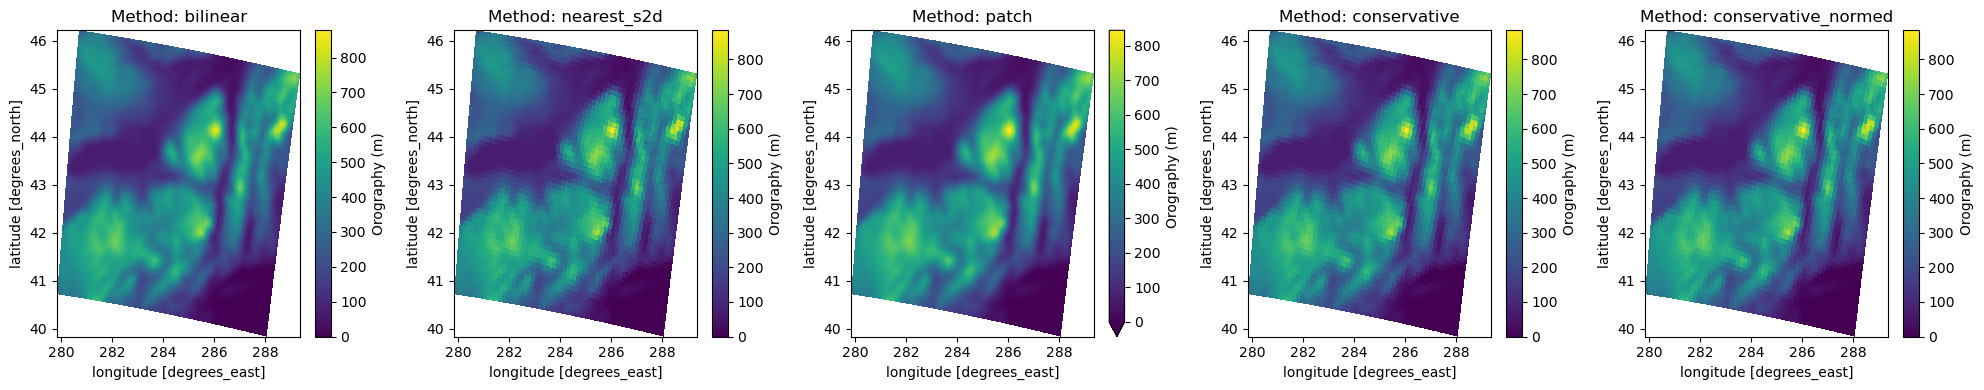

In [13]:
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt
eddev2_nys_cropped = xr.open_dataset('/network/rit/lab/basulab/Projects/DFS/DATA/EDDEv2_NYS/eddev2_nys_cropped_orography.nc').copy()
urma_nys = xr.open_dataset("/network/rit/lab/basulab/Projects/DFS/DATA/URMA_NYS/urma_nys_orography.nc")
target_grid = urma_nys

methods = ["bilinear", "nearest_s2d", "patch", "conservative", "conservative_normed"]
fig, axs = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), squeeze=False)

for i, method in enumerate(methods):
    need_bounds = method in ["conservative", "conservative_normed"]
    target_ds = add_bounds_2d(target_grid) if need_bounds else target_grid
    input_ds = add_bounds_2d(eddev2_nys_cropped) if need_bounds else eddev2_nys_cropped

    regridder_eddev2_to_urma = xe.Regridder(
        input_ds,
        target_ds,
        method=method,
        reuse_weights=False
    )
    regridded = regridder_eddev2_to_urma(eddev2_nys_cropped.orog)
    print(regridded.sizes)
    ax = axs[0, i]
    regridded.plot(ax=ax, x='longitude', y='latitude',vmin=0, cmap='viridis', cbar_kwargs={'label': 'Orography (m)'})
    ax.set_title(f'Method: {method}')
plt.tight_layout()
plt.show()

#### Full LR grid (256/5 x 288/5)

Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})


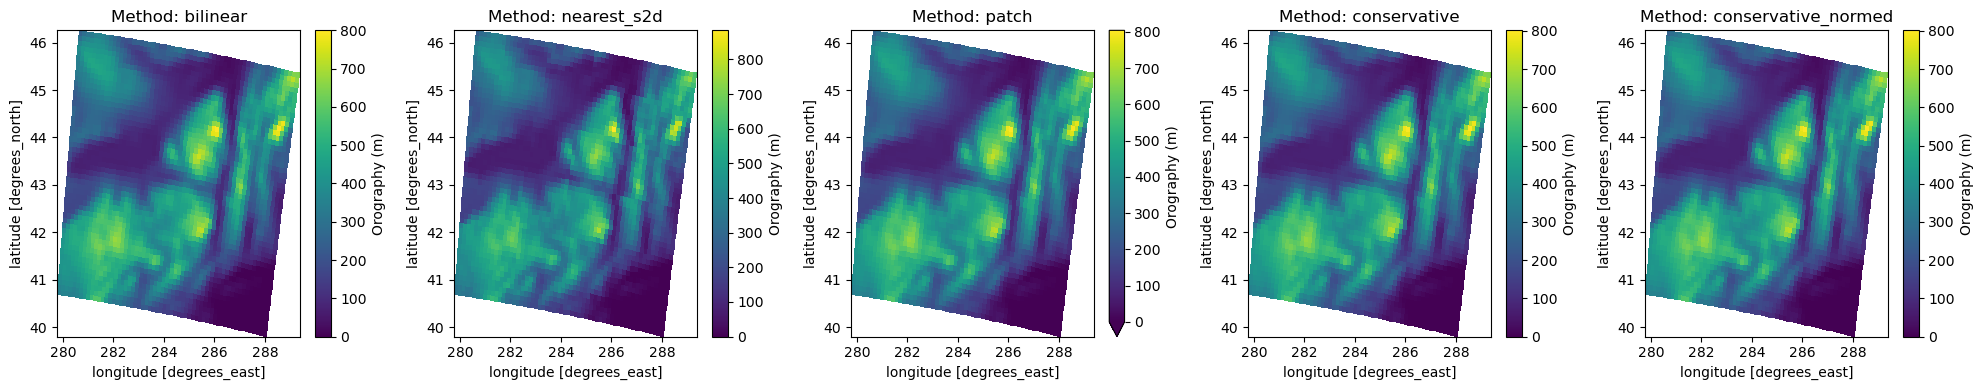

In [14]:
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt
eddev2_nys_cropped = xr.open_dataset('/network/rit/lab/basulab/Projects/DFS/DATA/EDDEv2_NYS/eddev2_nys_cropped_orography.nc').copy()
urma_nys = xr.open_dataset("/network/rit/lab/basulab/Projects/DFS/DATA/URMA_NYS/urma_nys_orography.nc")

sy = 5
sx = 5
target_grid = urma_nys.isel(
    y=slice(0,None,sy),
    x=slice(0,None,sx)
).copy()   # forces contiguous array

methods = ["bilinear", "nearest_s2d", "patch", "conservative", "conservative_normed"]
fig, axs = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), squeeze=False)

for i, method in enumerate(methods):
    need_bounds = method in ["conservative", "conservative_normed"]
    target_ds = add_bounds_2d(target_grid) if need_bounds else target_grid
    input_ds = add_bounds_2d(eddev2_nys_cropped) if need_bounds else eddev2_nys_cropped

    regridder_eddev2_to_urma = xe.Regridder(
        input_ds,
        target_ds,
        method=method,
        reuse_weights=False
    )
    regridded = regridder_eddev2_to_urma(eddev2_nys_cropped.orog)
    print(regridded.sizes)
    ax = axs[0, i]
    regridded.plot(ax=ax, x='longitude', y='latitude',vmin=0, cmap='viridis', cbar_kwargs={'label': 'Orography (m)'})
    ax.set_title(f'Method: {method}')
plt.tight_layout()
plt.show()

## ICON-DREAM-Global
- [Documentation](https://opendata.dwd.de/climate_environment/CDC/help/landing_pages/doi_landingpage_ICON-DREAM_v1-en.html)
- Individual variables for time ranges can be downloaded using [ICON-DREAM-Global/download_icon_dream.slurm](../ICON-DREAM-Global/download_icon_dream.slurm) 
- The raw data stored at `/network/rit/lab/basulab/RAW_DATA/ICON-DREAM-Global`
- At present, there are `DEN  PS  TD_2M  TKE  TOT_PREC  T_2M  U  U_10M  V  VMAX_10M  V_10M  WS  WS_10M  Z0` downloaded, but for the DFS, we may only use `TD_2M TOT_PREC T_2M WS_10 PS U_10M V_10M`
- Since, `WDIR_10M` doesn't exist, we will compute it. 

### Reading sample files to find their variable names inside

In [ ]:
import xarray as xr
source_dir = '/network/rit/lab/basulab/RAW_DATA/ICON-DREAM-Global'
vars = ["TD_2M", "TOT_PREC", "T_2M", "WS_10M", "PS", "U_10M", "V_10M", "VMAX_10M", "Z0"]
for var in vars:
    ds = xr.open_dataset(f"{source_dir}/{var}/ICON-DREAM-Global_202001_{var}_hourly.grb", engine='cfgrib', backend_kwargs={'indexpath': ''})
    candidates = [v for v in ds.data_vars if v not in {"lat", "lon", "time", "mtime"}]
    data_var = candidates[0] if candidates else next(iter(ds.data_vars))
    print(var, data_var, ds.sizes, ds[data_var].attrs.get("long_name"), ds[data_var].attrs.get("units"))
    if var == 'TOT_PREC':
        print('For precipitation ',ds[data_var].attrs)
    ds.close()

Key observationS from the above:
- the grb data is unstructrured, means regridding to a 2D grid is must followed by latitude and longitude attaching. 
- time dimension is not analysis always, but have three steps of forecasts.

### Processing/matching the time dimension
- The idea is to utilize the valid_time and its steps to make a uniform time dimension

In [ ]:
source_dir = '/network/rit/lab/basulab/RAW_DATA/ICON-DREAM-Global'
var="T_2M"
ds = xr.open_dataset(f"{source_dir}/{var}/ICON-DREAM-Global_202001_{var}_hourly.grb", engine='cfgrib', backend_kwargs={'indexpath': ''})['t2m']
print([
    (ds.isel(time=j, step=i).isnull().all().values.item(),
     ds.isel(time=j, step=i).valid_time.values)
    for j in [0,-1] for i in range(ds.step.size) 
])

In [ ]:
source_dir = '/network/rit/lab/basulab/RAW_DATA/ICON-DREAM-Global'
var="T_2M"
ds = xr.open_dataset(f"{source_dir}/{var}/ICON-DREAM-Global_202002_{var}_hourly.grb", engine='cfgrib', backend_kwargs={'indexpath': ''})['t2m']
print([
    (ds.isel(time=j, step=i).isnull().all().values.item(),
     ds.isel(time=j, step=i).valid_time.values)
    for j in [0,-1] for i in range(ds.step.size) 
])

- Remarkable it is, that the values falling outside a month of valid_time are set to nan.
- So, while processing, it is straightforward to convert the valid_time to 1D, set it as time dimension, and select only that month. 
- Simple. 

In [ ]:
import pandas as pd

# pick the month you want
yymonth = "202002"
source_dir = '/network/rit/lab/basulab/RAW_DATA/ICON-DREAM-Global'
var="T_2M"
ds = xr.open_dataset(f"{source_dir}/{var}/ICON-DREAM-Global_{yymonth}_{var}_hourly.grb", engine='cfgrib', backend_kwargs={'indexpath': ''})['t2m']

# stack to 1D, then use valid_time as the new time axis
ds_1d = (
    ds.stack(time_step=("time", "step"))
      .swap_dims({"time_step": "valid_time"})
      .drop_vars(["step","time","time_step","heightAboveGround"])
      .rename({"valid_time": "time"})
)

ds_month = ds_1d.sel(time=f"{yymonth[:4]}-{yymonth[4:]}")
ds_month

### Reading the global grid

In [ ]:
import xarray as xr 
ds = xr.open_dataset("ICON-DREAM-Global/ICON-DREAM-Global_grid.nc")
print(ds)
print(ds.sizes)
print(ds['clon'].min(), ds['clon'].max())

- This tells me that the grid coordinates are in radians. 
- There are a couple of caveats here.
    1. The ICON-DREAM is unstructured, so we can structure it only if we have a known structured grid matching the 13km resolution
    2. If we don't have a structured grid existing, then we either need to define our own or use any target grid of our choice
    3. Possible and certain options for regridding, which can fit in my ML pipeline are:
        -   xesmf regridding with locstream_in=True, but only supports `nearest_s2d`
        -   To open other options, such as to work for ['bilinear', 'nearest_s2d','patch','conservative','conservative_normed'], we first need to create a xesmf mesh, and then use that mesh in need.  
- For the DFS, our interest has been to downscale the EDDE to URMA, thus the URMA final grid itself has been our interest. 
- So, we can chose the urma_nys_orography.nc as our final grid
- Now, the point is, should we use the full grid with smooth filling, such as the `256*288`, or something with he same low resolution and low number of points, could be on the order of `50*52`
- To me, I would keep the unstructured ICON, but cropped to the NYS region, while writing to a zarr. This is what we followed to the EDDE and ERA5 as well, while saving them to zarrs. 
- The regridding only happens on the fly. 
- Also, if it helps, create a global mesh and NYS regional mesh. Use only the NYS regional mesh for the DL, while the global mesh may be helpful somewhere else.

### Subset/crop to the NYS
- Convert the radian lat lons to degrees
- Since the data is unstructured, first find a mask surrounding the NYS and save. 
- Use that mask to select the data within the NYS boundary for writing into zarr

In [ ]:
import numpy as np
import xarray as xr
grid = xr.open_dataset("ICON-DREAM-Global/ICON-DREAM-Global_grid.nc")[["clon","clat"]]

clon = grid["clon"]
clat = grid["clat"]
if clon.max() < 6.5:  # radians -> degrees
    clon = np.rad2deg(clon)
    clon = (clon + 360) % 360  # convert to [0, 360] range
    clat = np.rad2deg(clat)

lat_min, lat_max = 38, 48
lon_min, lon_max = 278, 292

mask = (clon >= lon_min) & (clon <= lon_max) & (clat >= lat_min) & (clat <= lat_max)

mask_ds = xr.Dataset(
    {"mask": (["values"], mask.data)},
    coords={
        "lon": (["values"], clon.data),  # xesmf requires coordinate names to be 'lon' and 'lat'
        "lat": (["values"], clat.data),
    },
)

mask_ds.to_netcdf("ICON-DREAM-Global/icon_global_nys_mask.nc")
mask_ds

### Based on the mask, crop and save ICON orography

In [ ]:
import xarray as xr
mask_ds = xr.open_dataset("ICON-DREAM-Global/icon_global_nys_mask.nc")
icon_static = xr.open_dataset("ICON-DREAM-Global/ICON-DREAM-Global_constant_fields.grb", engine='cfgrib', backend_kwargs={'indexpath': ''})
icon_orog = icon_static['HSURF']
icon_orog_nys = icon_orog.where(mask_ds['mask'], drop=True)
icon_orog_nys = icon_orog_nys.drop_vars(['time','step','surface','valid_time','level'])
icon_orog_nys = icon_orog_nys.rename('orog')
icon_orog_nys.to_netcdf("ICON-DREAM-Global/ICON-DREAM-Global_nys_orography.nc")
icon_orog_nys

### Create a mesh to the NYS boundary

In [ ]:
import numpy as np
import xarray as xr
from shapely.geometry import Polygon
from xesmf.backend import Mesh
import matplotlib.pyplot as plt
from xesmf.frontend import BaseRegridder, ds_to_ESMFgrid

# Load mask + full grid
mask_ds = xr.open_dataset("ICON-DREAM-Global/icon_global_nys_mask.nc")
mask = mask_ds["mask"].values.astype(bool)

grid = xr.open_dataset("ICON-DREAM-Global/ICON-DREAM-Global_grid.nc")

# Convert to degrees
clon = grid["clon"]
clat = grid["clat"]
if float(clon.max()) < 6.5:
    clon = np.rad2deg(clon)
    clat = np.rad2deg(clat)
    clon = (clon + 360) % 360

# Subset just what we need for mesh
clon_v = grid["clon_vertices"].isel(cell=mask).values
clat_v = grid["clat_vertices"].isel(cell=mask).values

# Convert vertices to degrees if needed
if np.nanmax(clon_v) < 6.5:
    clon_v = np.rad2deg(clon_v)
    clat_v = np.rad2deg(clat_v)
    clon_v = (clon_v + 360) % 360

# Build polygons and mesh
polys = [Polygon(list(zip(clon_v[i], clat_v[i]))) for i in range(clon_v.shape[0])]
mesh_in = Mesh.from_polygons(polys)

print(mesh_in)

### Regridding utilizing the mesh

#### Full HR grid (256 x 288)

In [ ]:
icon_orog_nys = xr.open_dataset("ICON-DREAM-Global/ICON-DREAM-Global_nys_orography.nc")["orog"]  # adjust variable/path
urma_nys = xr.open_dataset("urma_nys_orography.nc")
target_grid = urma_nys

methods = ["bilinear", "nearest_s2d", "patch", "conservative", "conservative_normed"]
fig, axs = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), squeeze=False)

for i, method in enumerate(methods):
    need_bounds = method in ["conservative", "conservative_normed"]
    target_ds = add_bounds_2d(target_grid) if need_bounds else target_grid

    grid_out, shape_out, out_dims = ds_to_ESMFgrid(target_ds, need_bounds=need_bounds, periodic=False)

    regridder = BaseRegridder(
        mesh_in,
        grid_out,
        method=method,
        input_dims=("values",),
        output_dims=out_dims,
        unmapped_to_nan=True,
    )

    regridded = regridder(icon_orog_nys)
    regridded = regridded.rename({"dummy_new": "y", "values_new": "x"})
    regridded = regridded.assign_coords(
        longitude=target_grid["longitude"],
        latitude=target_grid["latitude"],
    )
    print(f"{method}, regridded sizes: {regridded.sizes}")
    grid_out.destroy()  # free ESMF grid memory

    ax = axs[0, i]
    regridded.plot(ax=ax, x="longitude", y="latitude", vmin=0, cmap="viridis",
                   cbar_kwargs={"label": "Orography (m)"})
    ax.set_title(method)

plt.tight_layout()
plt.show()

#### Full LR grid (256/5 x 288/5)

In [ ]:
icon_orog_nys = xr.open_dataset("ICON-DREAM-Global/ICON-DREAM-Global_nys_orography.nc")["orog"]  # adjust variable/path
urma_nys = xr.open_dataset("urma_nys_orography.nc")
sy = 5
sx = 5
target_grid = urma_nys.isel(
    y=slice(0,None,sy),
    x=slice(0,None,sx)
).copy()   # forces contiguous array

methods = ["bilinear", "nearest_s2d", "patch", "conservative", "conservative_normed"]
fig, axs = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), squeeze=False)

for i, method in enumerate(methods):
    need_bounds = method in ["conservative", "conservative_normed"]
    target_ds = add_bounds_2d(target_grid) if need_bounds else target_grid

    grid_out, shape_out, out_dims = ds_to_ESMFgrid(target_ds, need_bounds=need_bounds, periodic=False)

    regridder = BaseRegridder(
        mesh_in,
        grid_out,
        method=method,
        input_dims=("values",),
        output_dims=out_dims,
        unmapped_to_nan=True,
    )

    regridded = regridder(icon_orog_nys)
    regridded = regridded.rename({"dummy_new": "y", "values_new": "x"})
    regridded = regridded.assign_coords(
        longitude=target_grid["longitude"],
        latitude=target_grid["latitude"],
    )
    print(f"{method}, regridded sizes: {regridded.sizes}")
    grid_out.destroy()  # free ESMF grid memory

    ax = axs[0, i]
    regridded.plot(ax=ax, x="longitude", y="latitude", vmin=0, cmap="viridis",
                   cbar_kwargs={"label": "Orography (m)"})
    ax.set_title(method)

plt.tight_layout()
plt.show()

## HRRR

```
s3://hrrrzarr/
  <family>/
    <YYYYMMDD>/
      <YYYYMMDD>_<HH>z_<run_type>.zarr/
        <level>/
          <variable>/
            <level>/        # data array group
              <variable>    # actual Zarr array
```
- The final variable is 

In [ ]:
import s3fs 
import xarray 

s3 = s3fs.S3FileSystem(anon=True)
def lookup(path):
    return s3fs.S3Map(path, s3=s3)
var = "APCP_acc_fcst"
path = f"hrrrzarr/sfc/20210101/20210101_00z_anl.zarr/surface/{var}" 
ds = xarray.open_mfdataset([lookup(path), lookup(f"{path}/surface")],engine="zarr")
ds

#### Examining the chunking and chunksize of surface level

In [ ]:
import math
da = ds[var]

chunks = da.encoding.get("chunks")
dtype_size = da.dtype.itemsize
chunk_nbytes = math.prod(chunks) * dtype_size
chunk_mb = chunk_nbytes / 1e6

print("variable     :", var)
print("dims         :", da.dims)
print("shape        :", da.shape)
print("dtype        :", da.dtype)
print("chunks       :", chunks)
print("chunk size MB:", chunk_mb)

### Cropping the orography to NYS

In [ ]:
import numpy as np
import pandas as pd
import xarray as xr
import s3fs
import zarr

HRRRZARR_BUCKET = "hrrrzarr"
GRID_INDEX_STORE = f"s3://{HRRRZARR_BUCKET}/grid/HRRR_chunk_index.zarr"

# Same bbox used in the script
BBOX = {
    "lat_min": 38.0,
    "lat_max": 48.0,
    "lon_min": -82.0,
    "lon_max": -68.0,
}

def open_grid_index():
    return xr.open_zarr(
        GRID_INDEX_STORE,
        consolidated=False,
        storage_options={"anon": True},
    )

def normalize_bbox_lon(lon):
    lon_max = float(np.nanmax(lon))
    if lon_max > 180.0:
        return (
            BBOX["lon_min"] + 360.0 if BBOX["lon_min"] < 0 else BBOX["lon_min"],
            BBOX["lon_max"] + 360.0 if BBOX["lon_max"] < 0 else BBOX["lon_max"],
        )
    return BBOX["lon_min"], BBOX["lon_max"]

def compute_crop_slices(grid):
    lat = grid["latitude"].values
    lon = grid["longitude"].values
    lon = (lon + 360) % 360 # ensure lon is in [0, 360] range for comparison
    lon_min, lon_max = normalize_bbox_lon(lon)

    mask = (
        (lat >= BBOX["lat_min"]) &
        (lat <= BBOX["lat_max"]) &
        (lon >= lon_min) &
        (lon <= lon_max)
    )

    ys, xs = np.where(mask)
    if ys.size == 0 or xs.size == 0:
        raise ValueError("No HRRR grid cells found inside the NYS bounding box.")

    return slice(int(ys.min()), int(ys.max()) + 1), slice(int(xs.min()), int(xs.max()) + 1)

def cropped_latlon(grid, y_slice, x_slice):
    lat = grid["latitude"].isel(y=y_slice, x=x_slice)
    lon = grid["longitude"].isel(y=y_slice, x=x_slice)
    lon = (lon + 360) % 360  # ensure longitude is in [0, 360] range
    return lat, lon

def build_orog_array_path(template_time="2025-01-01T00"):
    ts = pd.Timestamp(template_time)
    date_str = ts.strftime("%Y%m%d")
    hour_str = ts.strftime("%H")
    return (
        f"{HRRRZARR_BUCKET}/sfc/{date_str}/{date_str}_{hour_str}z_anl.zarr/"
        f"surface/HGT/surface/HGT"
    )

def read_hrrr_orog(template_time="2025-01-01T00"):
    grid = open_grid_index()
    y_slice, x_slice = compute_crop_slices(grid)
    lat, lon = cropped_latlon(grid, y_slice, x_slice)

    fs = s3fs.S3FileSystem(anon=True)
    mapper = fs.get_mapper(build_orog_array_path(template_time))
    arr = zarr.open(mapper, mode="r")

    # Analysis HGT is 2D: [y, x]
    data = np.asarray(arr[y_slice.start:y_slice.stop, x_slice.start:x_slice.stop], dtype=np.float32)

    orog = xr.DataArray(
        data,
        dims=("y", "x"),
        coords={
            "latitude": lat,
            "longitude": lon,
        },
        name="orog",
        attrs={
            "long_name": "surface geopotential height",
            "units": "m",
            "coordinates": "latitude longitude",
        },
    )
    return orog

orog = read_hrrr_orog("2025-01-01T00")
orog


In [ ]:
orog.plot(x="longitude", y="latitude", cmap="viridis", vmin=0, cbar_kwargs={"label": "Orography (m)"})

In [ ]:
orog.to_netcdf("HRRR/hrrr_orography_cropped_nys.nc")

### Regridding to URMA_NYS grid through xesmf regridders

#### Full HR grid (256 x 288)

Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})
Frozen({'y': 256, 'x': 288})


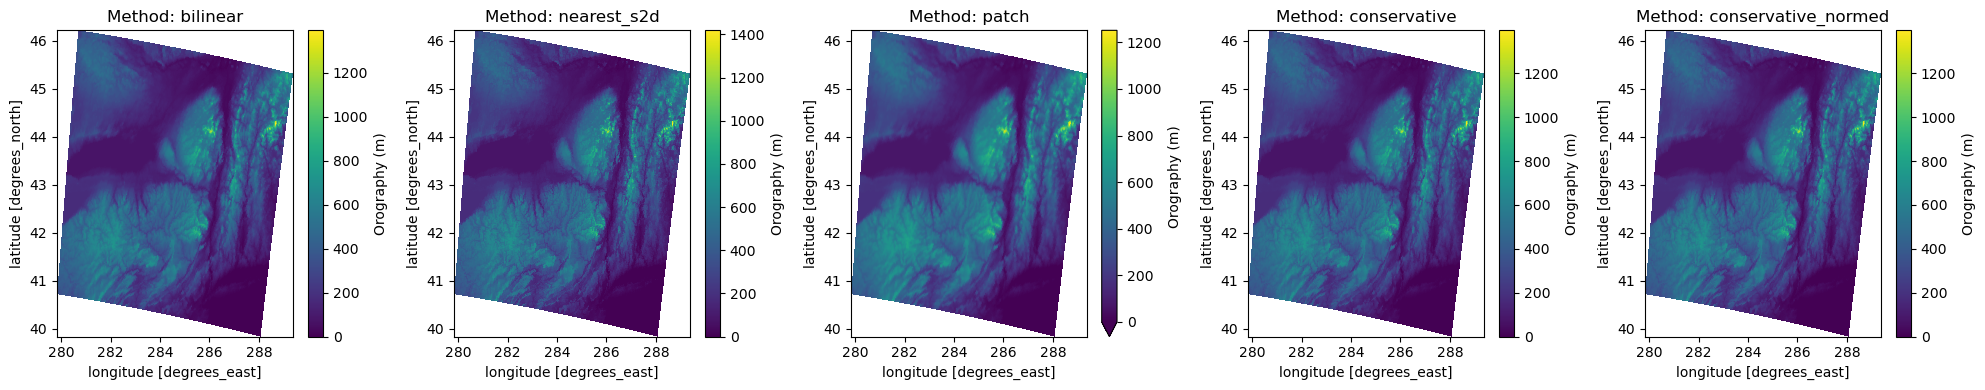

In [4]:
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt
hrrr_nys_cropped = xr.open_dataset('/network/rit/lab/basulab/Projects/DFS/DATA/HRRR_NYS/hrrr_orography_cropped_nys.nc').copy()
urma_nys = xr.open_dataset("/network/rit/lab/basulab/Projects/DFS/DATA/URMA_NYS/urma_nys_orography.nc")
target_grid = urma_nys

methods = ["bilinear", "nearest_s2d", "patch", "conservative", "conservative_normed"]
fig, axs = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), squeeze=False)

for i, method in enumerate(methods):
    need_bounds = method in ["conservative", "conservative_normed"]
    target_ds = add_bounds_2d(target_grid) if need_bounds else target_grid
    input_ds = add_bounds_2d(hrrr_nys_cropped) if need_bounds else hrrr_nys_cropped

    regridder_hrrr_to_urma = xe.Regridder(
        input_ds,
        target_ds,
        method=method,
        reuse_weights=False
    )
    regridded = regridder_hrrr_to_urma(hrrr_nys_cropped.orog)
    print(regridded.sizes)
    ax = axs[0, i]
    regridded.plot(ax=ax, x='longitude', y='latitude',vmin=0, cmap='viridis', cbar_kwargs={'label': 'Orography (m)'})
    ax.set_title(f'Method: {method}')
plt.tight_layout()
plt.show()

#### Full LR grid (256/5 x 288/5)

Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})
Frozen({'y': 52, 'x': 58})


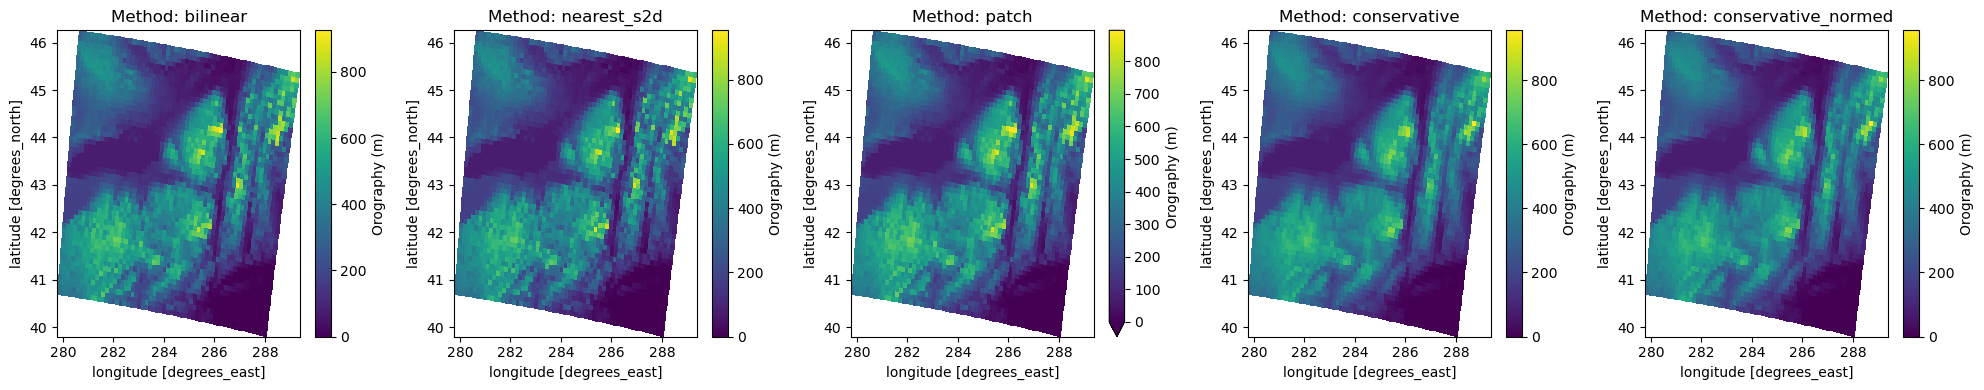

In [5]:
import xarray as xr
import xesmf as xe
import matplotlib.pyplot as plt
hrrr_nys_cropped = xr.open_dataset('/network/rit/lab/basulab/Projects/DFS/DATA/HRRR_NYS/hrrr_orography_cropped_nys.nc').copy()
urma_nys = xr.open_dataset("/network/rit/lab/basulab/Projects/DFS/DATA/URMA_NYS/urma_nys_orography.nc")

sy = 5
sx = 5
target_grid = urma_nys.isel(
    y=slice(0,None,sy),
    x=slice(0,None,sx)
).copy()   # forces contiguous array

methods = ["bilinear", "nearest_s2d", "patch", "conservative", "conservative_normed"]
fig, axs = plt.subplots(1, len(methods), figsize=(4 * len(methods), 4), squeeze=False)

for i, method in enumerate(methods):
    need_bounds = method in ["conservative", "conservative_normed"]
    target_ds = add_bounds_2d(target_grid) if need_bounds else target_grid
    input_ds = add_bounds_2d(hrrr_nys_cropped) if need_bounds else hrrr_nys_cropped

    regridder_hrrr_to_urma = xe.Regridder(
        input_ds,
        target_ds,
        method=method,
        reuse_weights=False
    )
    regridded = regridder_hrrr_to_urma(hrrr_nys_cropped.orog)
    print(regridded.sizes)
    ax = axs[0, i]
    regridded.plot(ax=ax, x='longitude', y='latitude',vmin=0, cmap='viridis', cbar_kwargs={'label': 'Orography (m)'})
    ax.set_title(f'Method: {method}')
plt.tight_layout()
plt.show()

## Ouranos
- Source documentation can be found at https://www.ouranos.ca/en/ouranos-climate-data/crcm5-cmip6
- Individual files can be accessed at https://pavics.ouranos.ca/twitcher/ows/proxy/thredds/catalog/birdhouse/disk2/ouranos/CORDEX/catalog.html

In [5]:
import xarray as xr
import numpy as np
from pathlib import Path

# ── 1. Collect all downloaded orography files ────────────────────────────────
orog_root = Path("Ouranos/raw")
files = sorted(orog_root.glob("**/*_full_areacella+orog_static.nc4"))
print(f"Found {len(files)} static orography files\n")

# ── 2. Load all files, keyed by a short label ────────────────────────────────
datasets = {}
for f in files:
    parts = f.relative_to(orog_root).parts          # (source_id, exp, variant, fname)
    real  = f.stem.split("_CRCM5_")[1].split("_")[0]  # v1-r1 or v1-r2
    label = f"{parts[0]}/{parts[1]}/{parts[2]} ({real})"
    datasets[label] = xr.open_dataset(f)

ref_label = list(datasets.keys())[0]
ref = datasets[ref_label]

# ── 3. Grid structure from reference file ────────────────────────────────────
print("=== OURANOS CRCM5 GRID STRUCTURE ===")
print(f"Reference : {ref_label}")
crs = ref["crs"]
print(f"  Projection   : rotated latitude-longitude")
print(f"  Pole lat/lon : {crs.attrs['grid_north_pole_latitude']} / {crs.attrs['grid_north_pole_longitude']}")
rlat_sp = float(np.diff(ref.rlat.values).mean())
rlon_sp = float(np.diff(ref.rlon.values).mean())
print(f"  rlat : n={len(ref.rlat):4d}  [{float(ref.rlat.min()):8.3f}, {float(ref.rlat.max()):8.3f}]  spacing={rlat_sp:.4f} deg  (~{rlat_sp*111:.1f} km)")
print(f"  rlon : n={len(ref.rlon):4d}  [{float(ref.rlon.min()):8.3f}, {float(ref.rlon.max()):8.3f}]  spacing={rlon_sp:.4f} deg  (~{rlon_sp*111:.1f} km)")
lat2d = ref["lat"].values
lon2d = ref["lon"].values
print(f"  lat (geographic) : {lat2d.min():.4f} to {lat2d.max():.4f} N")
print(f"  lon (geographic) : {lon2d.min():.4f} to {lon2d.max():.4f} E")
print(f"  orog : min={float(ref['orog'].min()):.1f} m   max={float(ref['orog'].max()):.1f} m")

# ── 4. Cross-product bit-identical check ─────────────────────────────────────
print("\n=== GRID CONSISTENCY ACROSS ALL PRODUCTS ===")
fields = {
    "rlat":     lambda ds: ds.rlat.values,
    "rlon":     lambda ds: ds.rlon.values,
    "lat (2D)": lambda ds: ds["lat"].values,
    "lon (2D)": lambda ds: ds["lon"].values,
    "orog":     lambda ds: ds["orog"].values,
}
ref_arrays = {k: fn(ref) for k, fn in fields.items()}

all_ok = True
for lbl, ds in list(datasets.items())[1:]:
    bad = [k for k, fn in fields.items() if not np.array_equal(fn(ds), ref_arrays[k])]
    tag = "PASS" if not bad else ("MISMATCH in: " + str(bad))
    if bad:
        all_ok = False
    print(f"  {lbl:<60s}  {tag}")

if all_ok:
    print("\n-> All grids are bit-identical -- single shared CRCM5 grid confirmed.")
else:
    print("\n-> Grids differ -- investigate mismatched fields above.")

# ── 5. Comparison vs EDDEv2 ──────────────────────────────────────────────────
print("\n=== COMPARISON vs EDDEv2 ===")
edde = xr.open_dataset("EDDEv2/eddev2_full_orography.nc")
edde_lat = edde["latitude"].values
edde_lon = edde["longitude"].values - 360   # convert 0-360 to -180/180

our_shape  = str(len(ref.rlat)) + " x " + str(len(ref.rlon))
edde_shape = str(edde.sizes["y"]) + " x " + str(edde.sizes["x"])
our_sp     = "~" + f"{rlat_sp*111:.1f}" + " km (uniform in rot.)"
edde_sp    = f"{edde.attrs['DX']/1000:.0f}" + " km x " + f"{edde.attrs['DY']/1000:.0f}" + " km"
our_latr   = f"{lat2d.min():.2f}" + " to " + f"{lat2d.max():.2f}" + " N"
edde_latr  = f"{edde_lat.min():.2f}" + " to " + f"{edde_lat.max():.2f}" + " N"
our_lonr   = f"{lon2d.min():.2f}" + " to " + f"{lon2d.max():.2f}" + " E"
edde_lonr  = f"{edde_lon.min():.2f}" + " to " + f"{edde_lon.max():.2f}" + " E"

print(f"  {'':12s}  {'Ouranos CRCM5':>30s}    {'EDDEv2 (WRF)':>30s}")
print(f"  {'Projection':<12s}  {'rotated lat-lon':>30s}    {'Lambert Conformal Conic':>30s}")
print(f"  {'Shape':<12s}  {our_shape:>30s}    {edde_shape:>30s}")
print(f"  {'Spacing':<12s}  {our_sp:>30s}    {edde_sp:>30s}")
print(f"  {'lat range':<12s}  {our_latr:>30s}    {edde_latr:>30s}")
print(f"  {'lon range':<12s}  {our_lonr:>30s}    {edde_lonr:>30s}")
print()
print("  Grids are NOT aligned -- different projections, origins, and axis structures.")
print("  Regridding required : rotated-pole -> LCC  (recommended: xesmf conservative)")
print("  NY domain (38-48 N, -82 to -68 E) is fully covered by both grids.")


Found 27 static orography files

=== OURANOS CRCM5 GRID STRUCTURE ===
Reference : CNRM-ESM2-1/historical/r1i1p1f2 (v1-r1)
  Projection   : rotated latitude-longitude
  Pole lat/lon : 42.5 / 83.0
  rlat : n= 628  [ -33.625,   35.345]  spacing=0.1100 deg  (~12.2 km)
  rlon : n= 655  [ -34.045,   37.895]  spacing=0.1100 deg  (~12.2 km)
  lat (geographic) : 6.3357 to 82.8449 N
  lon (geographic) : -179.9918 to 179.9958 E
  orog : min=0.0 m   max=3742.0 m

=== GRID CONSISTENCY ACROSS ALL PRODUCTS ===
  CNRM-ESM2-1/ssp126/r1i1p1f2 (v1-r1)                           PASS
  CNRM-ESM2-1/ssp245/r1i1p1f2 (v1-r1)                           PASS
  CNRM-ESM2-1/ssp370/r1i1p1f2 (v1-r1)                           PASS
  CanESM5/historical/r1i1p2f1 (v1-r1)                           PASS
  CanESM5/ssp126/r1i1p2f1 (v1-r1)                               PASS
  CanESM5/ssp245/r1i1p2f1 (v1-r1)                               PASS
  CanESM5/ssp370/r1i1p2f1 (v1-r1)                               PASS
  CanESM5/ssp585

/var/folders/2h/g1rp0qtn66sg1vj96zb2y9vr0000gn/T/ipykernel_82931/2587673483.py:68: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  edde_shape = str(edde.dims["y"]) + " x " + str(edde.dims["x"])
